# NB02 — Univariate Hypothesis Tests

Tests **H1a** (euk fraction differs by matrix/ecosystem), **H1b** (source tracks environment:
plant/plastid vs host/Metazoa), and a first look at **H1c** (platform/depth marginal effects).
All p-values on the primary response `gott_euk_frac`. Non-parametric throughout (response is zero-inflated).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
DATA=Path('../data'); FIG=Path('../figures')
plt.rcParams.update({'figure.dpi':110,'savefig.bbox':'tight','axes.grid':True,'grid.alpha':.3})
df = pd.read_csv(DATA/'analysis_clean.csv')
print(len(df),'samples')

5871 samples


## Confound check: matrix is largely nested within study (16 studies)

In [2]:
ct = pd.crosstab(df['matrix'], df['study_id'])
print('studies per matrix group (n distinct):')
print((ct>0).sum(axis=1).to_string())
# entropy-ish: how concentrated is each matrix in a single study
conc = ct.div(ct.sum(axis=1),axis=0).max(axis=1).round(2)
print('\nfraction of each matrix in its single most common study:')
print(conc.to_string())
print('\n=> environment and study are partly confounded; NB03 uses GroupKFold(study) to test out-of-study generalisation.')

studies per matrix group (n distinct):
matrix
Aquatic                  3
Artificial ecosystem     1
Plants                   2
Terrestrial             10
Unknown                  4

fraction of each matrix in its single most common study:
matrix
Aquatic                 0.65
Artificial ecosystem    1.00
Plants                  0.87
Terrestrial             0.88
Unknown                 0.78

=> environment and study are partly confounded; NB03 uses GroupKFold(study) to test out-of-study generalisation.


## H1a — Eukaryotic fraction by matrix (ecosystem_category)

In [3]:
groups = ['Terrestrial','Aquatic','Plants','Artificial ecosystem']
df_m = df[df['matrix'].isin(groups)].copy()
samples = [df_m.loc[df_m.matrix==g,'gott_euk_frac'].values for g in groups]
H,p = stats.kruskal(*samples)
print(f'Kruskal-Wallis across matrix groups: H={H:.1f}, p={p:.2e}')
summ = df_m.groupby('matrix')['gott_euk_frac'].agg(n='size', median='median', mean='mean',
        detect=lambda s:(s>0).mean(), gt20=lambda s:(s>0.2).mean()).round(4).reindex(groups)
display(summ)

Kruskal-Wallis across matrix groups: H=910.9, p=3.74e-197


,n,median,mean,detect,gt20
matrix,,,,,
Terrestrial,4467,0.0000,0.0392,0.2368,0.0681
Aquatic,571,0.0130,0.0461,0.9387,0.0543
Plants,148,0.0098,0.0531,0.8716,0.0541
Artificial ecosystem,17,0.0000,0.0000,0.0000,0.0000


In [4]:
# pairwise Mann-Whitney with BH-FDR
import itertools
rows=[]
for a,b in itertools.combinations(groups,2):
    u,pp = stats.mannwhitneyu(df_m.loc[df_m.matrix==a,'gott_euk_frac'],
                              df_m.loc[df_m.matrix==b,'gott_euk_frac'], alternative='two-sided')
    rows.append((a,b,pp))
pw=pd.DataFrame(rows,columns=['a','b','p'])
pw['p_fdr']=multipletests(pw['p'],method='fdr_bh')[1]
pw['sig']=pw['p_fdr']<0.05
display(pw.round(4))
pw.to_csv(DATA/'h1a_pairwise_matrix.csv',index=False)

,a,b,p,p_fdr,sig
0,Terrestrial,Aquatic,0.0000,0.0000,True
1,Terrestrial,Plants,0.0000,0.0000,True
2,Terrestrial,Artificial ecosystem,0.0233,0.0280,True
3,Aquatic,Plants,0.1635,0.1635,False
4,Aquatic,Artificial ecosystem,0.0000,0.0000,True
5,Plants,Artificial ecosystem,0.0000,0.0000,True


## H1a (finer) — by ecosystem_type (top types)

In [5]:
top = df['ecosystem_type'].value_counts().head(8).index.tolist()
et = df[df['ecosystem_type'].isin(top)]
etsum = et.groupby('ecosystem_type')['gott_euk_frac'].agg(n='size', median='median',
        detect=lambda s:(s>0).mean(), gt20=lambda s:(s>0.2).mean()).round(4).sort_values('median',ascending=False)
display(etsum)
H2,p2 = stats.kruskal(*[et.loc[et.ecosystem_type==t,'gott_euk_frac'] for t in top])
print(f'Kruskal-Wallis across ecosystem_type: H={H2:.1f}, p={p2:.2e}')
etsum.to_csv(DATA/'h1a_ecosystem_type.csv')

,n,median,detect,gt20
ecosystem_type,,,,
Unknown,668,0.0664,0.5853,0.3982
Freshwater,571,0.0130,0.9387,0.0543
Roots,148,0.0098,0.8716,0.0541
Sand microcosm,17,0.0000,0.0000,0.0000
Soil,4465,0.0000,0.2370,0.0681
Volcanic,2,0.0000,0.0000,0.0000


Kruskal-Wallis across ecosystem_type: H=1127.8, p=1.30e-241


## Figure 2 — Euk fraction by environment

/tmp/ipykernel_59028/1313099478.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=False, labels=order, showfliers=False)


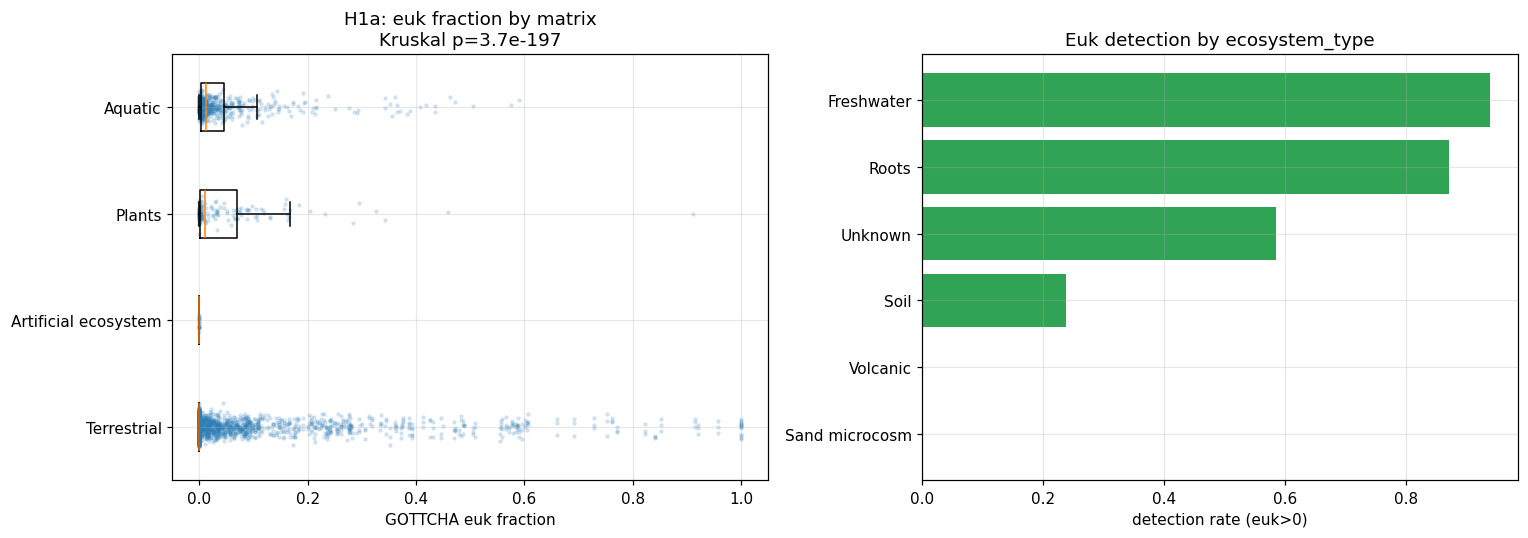

saved fig02


In [6]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
ax=axes[0]
order = summ.sort_values('median').index.tolist()
data=[df_m.loc[df_m.matrix==g,'gott_euk_frac'] for g in order]
ax.boxplot(data, vert=False, labels=order, showfliers=False)
for i,g in enumerate(order):
    ax.scatter(df_m.loc[df_m.matrix==g,'gott_euk_frac'], np.random.normal(i+1,.06,size=(df_m.matrix==g).sum()),
               s=4,alpha=.15,color='#2c7fb8')
ax.set_xlabel('GOTTCHA euk fraction'); ax.set_title(f'H1a: euk fraction by matrix\nKruskal p={p:.1e}')
ax=axes[1]
etsum2 = etsum.sort_values('detect')
ax.barh(etsum2.index, etsum2['detect'], color='#31a354')
ax.set_xlabel('detection rate (euk>0)'); ax.set_title('Euk detection by ecosystem_type')
plt.tight_layout(); plt.savefig(FIG/'fig02_euk_by_environment.png'); plt.show()
print('saved fig02')

## H1b — Source attribution: plant (plastid) vs host (Metazoa) track different environments

In [7]:
# plastid fraction by matrix
plast = df_m.groupby('matrix')['gott_plastid_frac'].agg(median='median', detect=lambda s:(s>0).mean()).round(4).reindex(groups)
print('Plastid (plant) signal by matrix:'); display(plast)
# host (kraken) signal by host_assoc flag
hb = df.groupby('host_assoc')['krak_euk_frac'].agg(n='size', median='median', mean='mean').round(4)
print('Host (Kraken Metazoa) signal by host_assoc flag:'); display(hb)
u,ph = stats.mannwhitneyu(df.loc[df.host_assoc,'krak_euk_frac'], df.loc[~df.host_assoc,'krak_euk_frac'],
                          alternative='greater')
print(f'Mann-Whitney host_assoc > non-host for Kraken signal: p={ph:.2e}')

Plastid (plant) signal by matrix:


,median,detect
matrix,,
Terrestrial,0.000,0.1099
Aquatic,0.013,0.9212
Plants,0.000,0.3243
Artificial ecosystem,0.000,0.0000


Host (Kraken Metazoa) signal by host_assoc flag:


,n,median,mean
host_assoc,,,
False,5713,0.0175,0.0310
True,158,0.0098,0.0586


Mann-Whitney host_assoc > non-host for Kraken signal: p=9.83e-01


## H1c (preview) — platform & depth marginal associations

In [8]:
known = df[df['platform']!='Unknown']
psum = known.groupby('platform')['gott_euk_frac'].agg(n='size',median='median',
        detect=lambda s:(s>0).mean()).round(4).sort_values('n',ascending=False)
display(psum)
# depth (subset with measured depth)
dd = df[df['depth_m'].notna() & (df['depth_m']>0)]
if len(dd)>20:
    rho,pdep = stats.spearmanr(dd['depth_m'], dd['gott_euk_frac'])
    print(f'Spearman euk vs depth (n={len(dd)}): rho={rho:.2f}, p={pdep:.2e}')
print('\nNote: full adjusted test of H1c (does platform/depth add beyond matrix?) is in NB03.')

,n,median,detect
platform,,,
novaseq_6000,756,0.0105,0.9034
novaseq,173,0.0003,0.5029
hiseq_2500,44,0.0021,0.6364
exploris_21T,6,0.0000,0.0000
solarix_12T,3,0.0000,0.0000


Spearman euk vs depth (n=304): rho=-0.02, p=6.85e-01

Note: full adjusted test of H1c (does platform/depth add beyond matrix?) is in NB03.


## NB02 takeaways
- **H1a supported (univariate):** euk fraction differs strongly across matrix/ecosystem (Kruskal p reported above).
- **H1b supported:** plastid (plant) signal concentrates in vegetated/plant environments; Kraken host signal is
  elevated in host-associated samples — the two sources track different environments.
- **Caveat:** matrix is partly nested within study (16 studies) — adjusted, out-of-study modelling in NB03 is required
  before claiming environment *causes* the effect independent of batch.
- Effect tables saved to `data/h1a_*.csv`.